In [1]:
import os
import gc
import re
import sys
import time
import math
import json
import random
import numpy as np
import pandas as pd
import typing as tp
from tqdm.auto import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

import ast
from pathlib import Path
from itertools import islice
from collections import Counter, defaultdict

import wave
import soundfile

import librosa
import soundfile as sf
from IPython.display import Audio, display

import torch
import torchaudio
from torchvision.transforms import v2 as tvt_v2

from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast

from collections import OrderedDict
from collections import Counter
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata

# Perch
sys.path.append('/kaggle/input/datasets/hengck23/pytorch-perchv2')

#from perchv2_onnx import * #infrence
from perchv2_pytorch import *
# Timm
import timm
print(f"Timm Version {timm.__version__}")
import glob
import warnings
warnings.filterwarnings("ignore")

Timm Version 1.0.25


In [2]:
!ls /kaggle/input/datasets/hengck23/pytorch-perchv2

perch_v2_backbone.effb3.pth  perchv2_onnx.py	 perch_v2_spectrogram.pth
perch_v2_no_dft.onnx	     perchv2_pytorch.py  run_demo.py


In [3]:
class CFG():
    SEED            = 42
    N_FOLDS         = 5
    FOLDS_LIST      = [0]
    base_dir        = "/kaggle/input/competitions/birdclef-2026"
    fold_dir        = "/kaggle/input/datasets/tatsuyayamamoto"
    ss_dir          = "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-ss-wav-data"
    label_dir       = "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-5fold-df-and-ss/data"
    perch_path      = "/kaggle/input/datasets/hengck23/pytorch-perchv2"
    fold_model_list = [
        "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo-fold1-lsehead-b0-model/models",
        "",
        "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo-fold3-lsehead-b0-model/models",
        "",
        ""
    ]
    # Model
    timm_model_name = "efficientnet_b0"
    # Librosa
    SAMPLING_RATE = 32_000
    N_FFT         = 2_048
    HOP_LEN       = 512# or 256 or 320
    N_MELS        = 128
    FMIN          = 20
    FMAX          = 16_000
    DURATION      = 5
    # Targets
    NUM_CLASS     = 234
    # normarize
    MEL_NORM      = "MinMax"#"standard"
    # segments & context
    SEGMENT_SEC   = 5
    CONTEXT_SEC   = 20 #OR 10
    HOP_SEC       = 2
    # WEIGHT
    RMS_THRESHOLD = 0.01
    SS_WEIGHT     = 1.5
    #PSEUDO_WEIGHT = 1.0
    # Augmentation
    # Noise
    NOISE_PROB   = 0.4
    # CutMix
    USE_CUTMIX    = True
    CUTMIX_PROB   = 0.6
    # Mel
    TOP_DB        = 60
    # Mask
    USE_AUG       = True
    SPEC_AUG_PROB = 0.5
    # Pseudo
    USE_PSEUDO      = True
    PSEUDO_THRESHOLD= 0.7
    # DataLoader
    BATCH_SIZE    = 8
    NUM_WORKERS   = os.cpu_count()
    # Optimizer
    lr            = 2e-5
    max_lr        = 1e-4
    weight_decay  = 1e-4
    # AdamW
    betas         = (0.9, 0.98)
    eps           = 1e-6
    # Sheduler
    pseudo_epochs = 3 # Create pseudo Model epochs
    max_epochs    = 6
    warmup_epochs = 1
    # Training 
    accumulation_steps = 4
    max_grad_norm      = 10
    print_freq         = 100
    es_round           = 3
    use_amp            = True
    
    if USE_PSEUDO:
        if len(fold_model_list)==0:
            pseudo_epochs = 3 # Create pseudo Model epochs
        max_epochs = 6
        use_form_pseudo_epoch = 1
    debug        = False
    pseudo_debug = False
    if debug:
        max_epochs = 2
        use_form_pseudo_epoch = 1
    
cfg = CFG()
print(f"Debug      : {cfg.debug}")
print(f"Batch size : {cfg.BATCH_SIZE}")
print(f"num workers: {cfg.NUM_WORKERS}")
print(f"fram       : {(cfg.SAMPLING_RATE*cfg.CONTEXT_SEC)/cfg.HOP_LEN}")

#128 周波数方向（mel bins）
#626 時間方向（time frames）

Debug      : False
Batch size : 8
num workers: 4
fram       : 1250.0


### Device

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device is {device}")

device is cuda


### SEED Everything

In [5]:
def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    torch.backends.cudnn.deterministic = True
    
seed_everything(cfg.SEED)

### Load Data

In [6]:
def safe_literal_eval(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []

def load_df(is_ss=True):
    if is_ss:
        df = pd.read_csv(os.path.join(cfg.ss_dir, "data", "ss_df.csv"))
        df["fold"] = -1
    else:
        df = pd.concat([pd.read_csv(os.path.join(cfg.fold_dir, f"bird-2026-train-fold{i}-wav-data", "data", f"fold_{i}.csv")) for i in range(cfg.N_FOLDS)], axis=0, ignore_index=True)
        df.drop(columns="idx", inplace=True)
        
    df["labels"] = df["labels"].apply(safe_literal_eval)
    
    print(f"DF Shape: {df.shape}")
    return df

def load_labels(path):
    with open(path, mode="r") as f:
        labels_dict = json.load(f)
    return {int(k):v for k, v in labels_dict.items()}

In [7]:
train_only = load_df(is_ss=False)
ss_only    = load_df()
print(f"Train & SS columns: {sorted(train_only.columns)==sorted(ss_only.columns)}")

DF Shape: (35378, 13)
DF Shape: (425, 13)
Train & SS columns: True


### Labels

In [8]:
idx2label = load_labels(os.path.join(cfg.label_dir, "idx2label.json"))
label2idx = {v:k for k, v in idx2label.items()}

### is pseudo

In [9]:
PSEUDO_SEC = 20
train_only["is_pseudo"] = 0

# 長い音だけ pseudo候補
train_only.loc[train_only["duration"] >= PSEUDO_SEC, "is_pseudo"] = 1

ss_only["is_pseudo"] = 0   # ← SS not pseudo

# 初期設定
train_only["pseudo_prob"] = 0.0
ss_only["pseudo_prob"]    = 0.0

### SS Group

In [10]:
site_pattern = re.compile(r'_(S\d+)_')

ss_only["site"]    = ss_only["filename"].apply(lambda x: m.group(1) if (m := site_pattern.search(x)) else None)
train_only["site"] = None

ss_only["site"].value_counts()

site
S22    272
S08     33
S15     32
S19     27
S23     24
S13     14
S09     11
S18      6
S03      6
Name: count, dtype: int64

### Concat SS + Train

In [11]:
merge_df = pd.concat([train_only, ss_only], axis=0, ignore_index=True)
if cfg.debug:
    merge_df = merge_df.sample(frac=0.02, random_state=cfg.SEED).reset_index(drop=True)
    display(merge_df.groupby("fold")["audio_id"].count())
print(merge_df.shape)
del train_only
_=gc.collect()

(35803, 16)


In [12]:
merge_df["site"].value_counts()

site
S22    272
S08     33
S15     32
S19     27
S23     24
S13     14
S09     11
S18      6
S03      6
Name: count, dtype: int64

### DataSet

In [13]:
class BirdWaveDataset(Dataset):
    def __init__(self, df, cfg, label2idx=label2idx ,mode="train"):
        self.df          = df
        self.mode        = mode
        self.cfg         = cfg
        self.sr          = cfg.SAMPLING_RATE
        self.segment_sec = cfg.SEGMENT_SEC
        self.context_sec = cfg.CONTEXT_SEC
        self.label2idx   = label2idx
        self.use_pseudo  = cfg.USE_PSEUDO


    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        wave, label, weight, audio_id, start, end = self.load_sample(index)
        
        # ---- noise ----
        if self.mode == "train" and np.random.rand() < self.cfg.NOISE_PROB:
            wave = wave + np.random.normal(0, 0.003, size=wave.shape)
            
        # ---- CutMix----
        if self.mode == "train":  
            r = np.random.rand()
            if r < self.cfg.CUTMIX_PROB:
                wave, label, weight = self.apply_cutmix_wave(wave, label, weight, index)
        # =====================
        # 🎯 final normalize
        # =====================
        rms  = np.sqrt(np.mean(wave**2))
        wave = wave * (0.1 / (rms + 1e-6))
        # or
        # target_rms = np.random.uniform(0.05, 0.15)
        # wave = wave * (target_rms / (rms + 1e-6))
        # wave = np.clip(wave, -1.0, 1.0)
        
        return {
            "wave"  : torch.tensor(wave,   dtype=torch.float32),
            "label" : torch.tensor(label,  dtype=torch.float32),
            "weight": torch.tensor(weight, dtype=torch.float32),
            "id"    : audio_id,
            "start" : torch.tensor(start, dtype=torch.long),
            "end"   : torch.tensor(end, dtype=torch.long)
        }
        
    def load_sample(self, index):
        row         = self.df.iloc[index]
        fold        = row["fold"]
        audio_id    = row["audio_id"]
        start       = int(np.floor(row["start"].item()))
        end         = int(np.floor(row["end"].item()))
        base_weight = row["weight"]
        labels      = row["labels"] # List
        is_ss       = row["is_ss"]
        is_pseudo   = row["is_pseudo"]
        pseudo_prob = row["pseudo_prob"]
        
        if is_ss:
            audio_path = os.path.join(cfg.fold_dir, "bird-2026-ss-wav-data", "audio", "SS", f"{audio_id}.wav")
        else:
            audio_path = os.path.join(cfg.fold_dir, f"bird-2026-train-fold{fold}-wav-data", "audio", f"fold_{fold}", f"{audio_id}.wav")

        # Audio Load
        wave, _ = sf.read(audio_path, dtype="float32")
        if wave.ndim == 2:
            wave = wave.mean(axis=1)
            # if Stereo
        
        wave      = wave[start*self.sr: end*self.sr]
        total_len = len(wave)/self.sr
        
        # crop + pad
        if self.mode == "train":
            wave = self.smart_crop(wave, total_len, duration=self.context_sec)
            wave = self.pad_audio(wave, self.context_sec, is_pseudo, is_ss)
        else:
            wave = self.center_crop(wave, total_len, duration=self.context_sec)
        
        # Label
        label = self.build_label(row)
        # Weight
        weight = self.compute_weight(
            wave, base_weight, is_ss, is_pseudo, pseudo_prob
        )
        return wave, label, weight, audio_id, start, end

    # =====================
    # 🎬 Center Crop [Valid]
    # =====================
    def center_crop(self, wave, total_len, duration):
        target_len = int(duration * self.sr)
    
        if total_len >= duration:
            start = (total_len - duration) / 2
            start_sample = int(start * self.sr)
            end_sample   = int((start + duration) * self.sr)
            wave = wave[start_sample:end_sample]
        
        # 🔥 pad
        if len(wave) < target_len:
            pad_len = target_len - len(wave)
            pad = np.zeros(pad_len, dtype=wave.dtype)
            wave = np.concatenate([wave, pad])
        
        return wave

    
    # =====================
    # 🐔　 Birdsong
    # ===================== 
    def get_active_regions(self, wave, downsampling=True):
        if downsampling:
            wave = wave[::4]  # 8 → 4
    
        # フレーム分割
        frame_size = self.cfg.HOP_LEN*2
        hop        = self.cfg.HOP_LEN
    
        rms = []
        for i in range(0, len(wave) - frame_size, hop):
            frame = wave[i:i+frame_size]
            rms.append(np.sqrt(np.mean(frame**2)))
    
        rms = np.array(rms)
    
        # Threshold
        threshold = np.percentile(rms, 80)  
    
        active = rms > threshold
    
        return active, rms
        
    # =====================
    # 🎬 Crop
    # =====================
    def smart_crop(self, wave, total_len, duration, p_active=0.7):
        if total_len <= duration:
            return wave
    
        active, energy = self.get_active_regions(wave)
    
        dur_samples = int(duration * self.sr)
    
        if np.random.rand() < p_active and active.sum() > 3:
            idx   = np.where(active)[0]
            frame = np.random.choice(idx)
    
            hop    = self.cfg.HOP_LEN
            center = frame * hop
    
            start = max(0, center - dur_samples // 2)
            end   = start + dur_samples
    
            if end > len(wave):
                end   = len(wave)
                start = end - dur_samples
        else:
            start = np.random.randint(0, len(wave) - dur_samples)
            end   = start + dur_samples
    
        cropped = wave[int(start):int(end)]
    
        # 無音防止
        if np.sqrt(np.mean(cropped**2)) < 0.01:
            start = np.random.randint(0, len(wave) - dur_samples)
            end   = start + dur_samples
            cropped = wave[int(start):int(end)]
    
        return cropped
        
    # =====================
    # 🪾 Padding Audio
    # =====================
    def pad_audio(self, wave, duration, is_pseudo, is_ss):
        target_len = int(duration * self.sr)
    
        if len(wave) >= target_len:
            return wave
    
        ratio = len(wave) / target_len
    
        # --- 超短い ---
        if ratio < 0.3:
            return self.pad_with_silence(wave, target_len)
    
        # --- 中くらい ---
        elif ratio < 0.6:
            if np.random.rand() < 0.5:
                return self.smooth_repeat(wave, target_len)
            else:
                return self.pad_with_silence(wave, target_len)
    
        # --- 長め ---
        else:
            p = np.random.rand()
            if p < 0.3:
                return self.pad_repeat_with_offset(wave, target_len)
            elif p < 0.6:
                return self.smooth_repeat(wave, target_len)
            else:
                return self.pad_with_silence(wave, target_len)
    
    
    # ===== safe crop =====
    def short_random_crop(self, wave, target_len):
        if len(wave) <= target_len:
            return wave
        start = np.random.randint(0, len(wave) - target_len + 1)
        return wave[start:start+target_len]
    
    
    def pad_repeat_with_offset(self, wave, target_len):
        repeat_num = int(np.ceil(target_len / len(wave)))
        wave = np.tile(wave, repeat_num)
        return self.short_random_crop(wave, target_len)
    
    
    def smooth_repeat(self, wave, target_len):
        if len(wave) < 100:
            return self.pad_with_silence(wave, target_len)
    
        repeat_num = int(np.ceil(target_len / len(wave)))
        wave = np.tile(wave, repeat_num)
    
        # ランダム開始位置（リーク防止）
        start = 0
        if len(wave) > target_len:
            start = np.random.randint(0, len(wave) - target_len)
    
        return wave[start:start+target_len]

    def pad_with_silence(self, wave, target_len):
        pad_len = target_len - len(wave)
        pad     = np.zeros(pad_len, dtype=wave.dtype)
        
        if np.random.rand() < 0.5:
            return np.concatenate([wave, pad])
        else:
            return np.concatenate([pad, wave])


    # =====================
    # 🎯 label処理
    # =====================
    def build_label(self, row):
        label = np.zeros(self.cfg.NUM_CLASS, dtype=np.float32)
    
        # ---- pseudo branch
        use_pseudo = row.get("use_pseudo", 0)
        use_pseudo = 0 if pd.isna(use_pseudo) else int(use_pseudo)
        
        if self.use_pseudo and use_pseudo == 1:
            
            pseudo_label = row.get("pseudo_label", None)
                        
            if isinstance(pseudo_label, (list, np.ndarray)):
                pseudo_label = np.array(pseudo_label, dtype=np.float32)
                pseudo_label = np.nan_to_num(
                    pseudo_label,
                    nan=0.0,
                    posinf=0.0,
                    neginf=0.0
                )
                
                if np.isnan(pseudo_label).any():
                    print("NaN in pseudo_label [Dataset]")
    
                # ---- safe conf
                conf = float(row.get("pseudo_prob", 0.0))
                conf = np.clip(conf, 0.0, 1.0)
                # 🔥 強すぎ防止
                conf = conf * 0.3
                
                # ---- real label
                real_label  = np.zeros(self.cfg.NUM_CLASS, dtype=np.float32)

                labels_list = row.get("labels", [])
                if not isinstance(labels_list, (list, tuple, np.ndarray)):
                    labels_list = []
                    
                for l in labels_list:
                    if isinstance(l, str):
                        l = self.label2idx.get(l, None)
                    if l is not None and pd.notna(l):
                        real_label[int(l)] = 1.0
                        
                pseudo = pseudo_label.copy()
                pseudo[real_label > 0] = 0
                pseudo_sum = pseudo.sum()
                if pseudo_sum > 1e-8:
                    pseudo = pseudo / pseudo_sum
                else:
                    pseudo = np.zeros_like(pseudo)
                    
                out = real_label + conf * pseudo
                out = np.clip(out, 0, 1)
                
                # out = (1 - conf) * real_label + conf * pseudo_label
                # out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

                # Debug
                if use_pseudo == 1 and self.cfg.pseudo_debug:
                    real_idx   = np.where(real_label > 0)[0]
                    pseudo_top = np.argsort(pseudo_label)[-5:][::-1]
                    out_top    = np.argsort(out)[-5:][::-1]
                
                    print("\n===== PSEUDO DEBUG =====")
                    print("conf:", conf)
                
                    print("Real label idx:")
                    print(real_idx)
                
                    print("Pseudo top5:")
                    for idx in pseudo_top:
                        print(idx, float(pseudo_label[idx]))
                
                    print("Mixed top5:")
                    for idx in out_top:
                        print(idx, float(out[idx]))
                
                return out.astype(np.float32)
    
        # ---- fallback (real)
        for l in row["labels"]:
            if isinstance(l, str):
                l = self.label2idx.get(l, None)
            if l is not None:
                label[int(l)] = 1.0
    
        return label
        
        
    # =====================
    # 🏋️‍♀️ Weight
    # =====================
    def compute_weight(self, wave, base_weight, is_ss, is_pseudo, pseudo_prob):
        weight = base_weight

        # ---- RMS（無音除去）
        rms = np.sqrt(np.mean(wave**2))
        if rms < self.cfg.RMS_THRESHOLD:
            weight *= 0.3

        # ---- SS強化
        if is_ss:
            weight *= self.cfg.SS_WEIGHT  # eg: 1.5

        # ---- pseudo
        if is_pseudo:
            weight *= 0.1 * np.sqrt(pseudo_prob)
            #weight *= np.sqrt(pseudo_prob)
            #weight *= (0.1 + pseudo_prob)
            #weight *= 0.5
            #weight *= (cfg.PSEUDO_WEIGHT + cfg.PSEUDO_WEIGHT * pseudo_prob)
            #weight *= (cfg.PSEUDO_WEIGHT * (0.1 + pseudo_prob))
            # cfg.PSEUDO_WEIGHT=0.5
            """
            np.sqrt
            eg:
            0.55 -> 0.74
            0.90 -> 0.95
            """

        return weight

    # =====================
    # 🎵 mel
    # =====================
    def wave_to_mel_base(self, wave, top_db=CFG.TOP_DB):
        mel = librosa.feature.melspectrogram(
            y=wave,
            sr=self.sr,
            n_mels=self.cfg.N_MELS,
            fmin=self.cfg.FMIN,
            fmax=self.cfg.FMAX,
            hop_length=self.cfg.HOP_LEN,
            n_fft=self.cfg.N_FFT,
        )
    
        mel = librosa.power_to_db(mel, top_db=top_db).astype(np.float32)
    
        if self.cfg.MEL_NORM == "standard":
            mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        elif self.cfg.MEL_NORM == "MinMax":
            """
            # 0   dB   = 最大音
            # -80 dB   = ほぼ無音
            """
            mel = (mel + top_db) / top_db
            mel = np.clip(mel, 1e-6, 1.0) #極小値を0にしない
            mel = np.power(mel, 0.7)      # ガンマ補正　 small sound
            
        mel = mel[np.newaxis, :, :]
        return mel
    
    # =====================
    # 🐤 |🐴 CutMix
    # =====================
    def rms(self, x):
        return np.sqrt(np.mean(x**2))
        
    def apply_cutmix_wave(self, wave, label, weight, index):
        if not self.cfg.USE_CUTMIX:
            return wave, label, weight
    
        if np.random.rand() > self.cfg.CUTMIX_PROB:
            return wave, label, weight
    
        cur = self.df.iloc[index]
        same_fold_df = self.df[self.df["fold"] == cur["fold"]]
    
        # =====================
        # 🎯 candidate sampling
        # =====================
        # ラベル統計
        all_labels   = self.df["labels"].explode().values
        label_counts = Counter(all_labels)
        
        cur_labels = set(cur["labels"])
        
        # overlap計算
        overlaps = same_fold_df["labels"].apply(
            lambda x: len(cur_labels & set(x))
        )
        
        valid_mask = (
            (same_fold_df.index != index) &
            (same_fold_df["audio_id"] != cur["audio_id"])
        )
        
        r = np.random.rand()
        
        # ===== 分岐 =====
        if r < 0.6:
            # 60%: 似てる（安定学習）
            valid_mask &= (overlaps > 0)
        
        elif r < 0.85:
            # 25%: ランダム（汎化）
            pass
        
        else:
            # 15%: rare強化
            pass
        
        candidates = same_fold_df[valid_mask]
        
        if len(candidates) == 0:
            return wave, label, weight
        
        overlaps = overlaps[valid_mask].values
        
        # rare weight
        rare_weights = candidates["labels"].apply(
            lambda x: np.mean([1.0 / (label_counts[l] + 1e-6) for l in x])
        ).values
        
        # ===== sampling =====
        probs = (overlaps + 1) * (rare_weights ** 0.5) + 1e-6
        probs = probs / probs.sum()
        
        choice_index = np.random.choice(candidates.index.values, p=probs)
        
        wave2, label2, weight2, _, _, _ = self.load_sample(choice_index)

        # =====================
        # 🎯 長さ合わせ
        # =====================
        min_len = min(len(wave), len(wave2))
        wave1   = wave[:min_len]
        wave2   = wave2[:min_len]
        
        # =====================
        # 🎯 RMS Normalize
        # =====================
        wave1 = wave1 / (self.rms(wave1) + 1e-6)
        wave2 = wave2 / (self.rms(wave2) + 1e-6)
        
        # =====================
        # 🎯 wave2位置補正
        # =====================
        energy = np.abs(wave2)
        energy = np.convolve(energy, np.ones(1024)/1024, mode='same')
        
        peak = np.argmax(energy)
        
        center = len(wave2) // 2
        shift = center - peak
        
        wave2_new = np.zeros_like(wave2)
        
        if shift > 0:
            wave2_new[shift:] = wave2[:-shift]
        elif shift < 0:
            wave2_new[:shift] = wave2[-shift:]
        else:
            wave2_new = wave2.copy()
        
        wave2 = wave2_new
        
        # 無音除外
        active_ratio = np.mean(np.abs(wave2) > 0.01)
        if active_ratio < 0.05:
            return wave1, label, weight
        
        # =====================
        # 🎯 mel作成（位置決定用）
        # =====================
        mel1 = self.wave_to_mel_base(wave1)
        mel2 = self.wave_to_mel_base(wave2)
        
        # =====================
        # 🎯 gain
        # =====================
        gain = np.random.uniform(0.8, 1.2)
        wave2 = wave2 * gain
    
        # =====================
        # 🎯 フィルタ（そのまま流用）
        # =====================
        if mel2.mean() < 0.15:
            return wave1, label, weight
    
        ratio = mel2.mean() / (mel1.mean() + 1e-6)
        
        if ratio < 0.3 or ratio > 3.0:
            return wave1, label, weight
    
        # =====================
        # 🎯 pseudo制御
        # =====================
        is_pseudo_1 = cur["is_pseudo"]
        is_pseudo_2 = same_fold_df.loc[choice_index, "is_pseudo"]
    
        if is_pseudo_1 and is_pseudo_2:
            return wave, label, weight
    
        # =====================
        # 🎯 cut位置（melベース）
        # =====================
        _, _, T = mel1.shape
    
        cut_ratio = np.random.uniform(0.2, 0.4)
        cut_len   = int(T * cut_ratio)
    
        energy2 = mel2.mean(axis=1).squeeze()
        energy2 = energy2 ** 1.5 + 1e-6
    
        window_energy = np.convolve(energy2,
                                    np.ones(cut_len),
                                    mode='valid'
                                   )
    
        probs       = window_energy / window_energy.sum()
        start_frame = np.random.choice(np.arange(len(window_energy)), p=probs)
        end_frame   = start_frame + cut_len
    
        # =====================
        # 🎯 mel → wave index変換（超重要）
        # =====================
        total_samples     = len(wave1)
        samples_per_frame = total_samples // T
    
        start_sample = start_frame * samples_per_frame
        end_sample   = end_frame   * samples_per_frame
    
        # 安全処理
        end_sample = min(end_sample, total_samples)
    
        # =====================
        # 🎯 wave cutmix
        # =====================
        wave_new = wave1.copy()
    
        cut_len_sample = end_sample - start_sample
        if cut_len_sample <= 0:
            return wave1, label, weight
    
        # フェード（境界なめらか）
        alpha = np.linspace(0, 1, cut_len_sample)
        
        if np.random.rand() < 0.5:
            fade = np.sin(np.linspace(0, np.pi, cut_len_sample))
        else:
            fade = alpha  # 片側フェード
        
    
        wave_new[start_sample:end_sample] = (
            wave1[start_sample:end_sample] * (1 - fade) +
            wave2[start_sample:end_sample] * fade
        )
    
        # =====================
        # 🎯 label mix（面積比例）
        # =====================
        # lam
        lam = 1.0 - (cut_len_sample / total_samples)

        # 局所energy（cut部分）
        energy1_local = np.mean(wave1[start_sample:end_sample]**2)
        energy2_local = np.mean(wave2[start_sample:end_sample]**2)
        
        # 全体energy（安定化）
        energy1_global = np.mean(wave1**2)
        energy2_global = np.mean(wave2**2)
        
        # ブレンド
        energy1 = 0.7 * energy1_local + 0.3 * energy1_global
        energy2 = 0.7 * energy2_local + 0.3 * energy2_global
        
        lam_energy = energy1 / (energy1 + energy2 + 1e-6)
        
        lam = 0.5 * lam + 0.5 * lam_energy
        # clip
        lam = np.clip(lam, 0.2, 0.95)
        
        label_new  = lam * label + (1 - lam) * label2
        weight_new = lam * weight + (1 - lam) * weight2
            
        return wave_new, label_new, weight_new

### Site Grobal sample

In [14]:
def sample_site(x):
    """
    eg:
    S22 : 272 -> 20
    S18 : 6   -> 2
    """
    n = len(x)
    valid_n = max(2, int(n * 0.15))
    valid_n = min(valid_n, 20)
    return x.sample(n=valid_n, random_state=42)

### DataLoader

In [15]:
def worker_init_fn(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def get_dataloaders(fold, train_df, valid_df, ss_df=None, cfg=cfg):
    seed_everything(cfg.SEED)
    if cfg.debug:
        print("=== BEFORE DATALOADER ===")
        print(train_df.columns)
        print(train_df["use_pseudo"].value_counts())
        
    dataloaders = {}
    if ss_df is not None:
        ss_valid = (ss_df.groupby("site", group_keys=False).apply(sample_site))
        # drop
        ss_train = ss_df.drop(ss_valid.index)
        ss_train.loc[ss_train["site"] == "S22", "is_ss_pseudo"] = 1
        assert set(ss_valid.index) & set(ss_train.index) == set()
        
        # add
        train_df = pd.concat([train_df, ss_train], ignore_index=True)
        # concat
        valid_df = pd.concat([valid_df, ss_valid],ignore_index=True)

        # Site
        site_train = (train_df["site"].dropna().value_counts().to_dict())
        site_valid = (valid_df["site"].dropna().value_counts().to_dict())
    
    print(f"Train Length: {len(train_df):,}")
    print(f"Valid Length: {len(valid_df):,}")
    print()
    print(f"SS in Train           : {len(train_df[train_df["is_ss"]==1]):,}")
    print(f"Train       Speceis   : {train_df["labels"].explode().nunique():,}")
    print(f"SS in Train Species   : {train_df.loc[train_df["is_ss"]==1, "labels"].explode().nunique():,}")
    print(f"Site : {site_train}")
    print()
    print(f"SS in Valid           : {len(valid_df[valid_df["is_ss"]==1]):,}")
    print(f"Valid       Species   : {valid_df["labels"].explode().nunique():,}")
    print(f"Valid in Train Species: {len(set(train_df["labels"].explode()).intersection(set(valid_df["labels"].explode())))}")
    print(f"Site : {site_valid}")
    print(f"Diffence    Species   : {list(set(valid_df["labels"].explode()).difference(set(train_df["labels"].explode())))}")

    train_dataset = BirdWaveDataset(train_df, cfg, mode="train")
    valid_dataset = BirdWaveDataset(valid_df, cfg, mode="valid")
    
    g = torch.Generator()
    g.manual_seed(cfg.SEED)
    
    dataloaders["train"] = DataLoader(train_dataset,
                                      batch_size=cfg.BATCH_SIZE,
                                      shuffle=True,
                                      worker_init_fn=worker_init_fn,
                                      generator=g,
                                      num_workers=cfg.NUM_WORKERS,
                                      pin_memory=True,
                                      drop_last=True
                                     )
    
    dataloaders["valid"] = DataLoader(valid_dataset,
                                      batch_size=cfg.BATCH_SIZE*2,
                                      shuffle=False,
                                      num_workers=cfg.NUM_WORKERS,
                                      pin_memory=True,
                                      drop_last=False
                                     )
    return dataloaders

### Model

input audio
   ↓
 ┌───────────────┐
 │               │
timm (student)   perch (teacher)
 │               │
emb_s           emb_t
 │               │
 └── lossで近づける ──┘

wave
|  ----->CNN encoder
|            |
|  GAP+Liner     LSEpool + MLP
|     |                 |
|  distill_feat        logit     
|     |                 |
perch concat 1536      234
      |                 |
    MSE Loss           BCE Loss


#### Head

In [16]:
class LSEHead(nn.Module):
    def __init__(self, 
                 num_features, 
                 num_classes, 
                 dropout=0.2, 
                 tau=1.0
                ):
        super().__init__()
        self.tau = nn.Parameter(torch.tensor(tau))

        self.cls_fc = nn.Sequential(
            nn.Linear(num_features, num_features),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, h):
        # h: (B, C, Freq, Time)

        h = torch.mean(h, dim=2)     # (B, C, Time)
        h = h.transpose(1, 2)        # (B, Time, C)

        timewise_logits = self.cls_fc(h)  # (B, Time, C)
        
        logits = torch.logsumexp(timewise_logits / self.tau, dim=1) * self.tau
        logits = logits - math.log(timewise_logits.size(1))
        return logits

In [17]:
class perchCnnModel(nn.Module):
    def __init__(self, 
                 cfg=cfg, 
                 model_name=cfg.timm_model_name,
                 num_classes=cfg.NUM_CLASS,
                 timm_pretrained=True,
                 perch_pretrained=True,
                 head_dropout=0.2, 
                 lse_temperature=0.5
                ):
        
        super().__init__()
        """
        model    : efficientnet_b0
        num_class: 234
        """
        self.cfg = cfg
        # Timm
        self.timm_backbone = timm.create_model(model_name, 
                                               pretrained=timm_pretrained, 
                                               in_chans=1,
                                               global_pool="", 
                                               num_classes=0
                                              )
        # Perch
        self.perch_frontend = Perch2Frontend()
        self.perch_backbone = Perch2EfficientB3()
        
        if perch_pretrained:# hengck23 finetune
            frontend_path = os.path.join(cfg.perch_path, "perch_v2_spectrogram.pth")
            backbone_path = os.path.join(cfg.perch_path, "perch_v2_backbone.effb3.pth")
            f_state = torch.load(frontend_path, map_location=device)
            b_state = torch.load(backbone_path, map_location=device)
            self.perch_frontend.load_state_dict(f_state)
            self.perch_backbone.load_state_dict(b_state)
            
            for p in self.perch_frontend.parameters():
                p.requires_grad = False
            
            for p in self.perch_backbone.parameters():
                p.requires_grad = False
        
        in_features  = self.timm_backbone.num_features #1280
        out_features = 1536
        #self.distill_head = nn.Linear(in_features, out_features)
        self.distill_head = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.ReLU(),
            nn.Linear(out_features, out_features)
        )
        self.proj         = nn.Linear(in_features, out_features)
        self.head         = LSEHead(in_features, num_classes, head_dropout, lse_temperature)
        self._init_weights()


        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=cfg.SAMPLING_RATE,
            n_fft=cfg.N_FFT,
            hop_length=cfg.HOP_LEN,
            n_mels=cfg.N_MELS,
            f_min=cfg.FMIN,
            f_max=cfg.FMAX,
            power=2.0, 
            center=True,
            norm="slaney",
            mel_scale="slaney"
        )
        """
        center=True,
        norm="slaney",
        mel_scale="slaney"
        
        """
        
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB(top_db=cfg.TOP_DB)

    def _init_weights(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.01)
                nn.init.constant_(m.bias, 0.0)

    
    def waves_to_mels_batch_fast(self, waves: torch):
        """
        waves : (B, N, L)  on GPU
        return: (B, N, 1, n_mels, time)
        """
        B, N, L = waves.shape
    
        # (B*N, L)
        waves = waves.view(B * N, L)
    
        # MelSpectrogram (GPU)
        mel = self.mel_transform(waves) # (B*N, n_mels, time)
    
        # dB
        mel = self.amplitude_to_db(mel) # (B*N, n_mels, time)
    
        # Normalize
        if self.cfg.MEL_NORM == "standard":
            mean = mel.mean(dim=(1,2), keepdim=True)
            std  = mel.std(dim=(1,2), keepdim=True)
            mel  = (mel - mean) / (std + 1e-6)
    
        elif self.cfg.MEL_NORM == "MinMax":
            mel = (mel + self.cfg.TOP_DB) / self.cfg.TOP_DB
            mel = torch.clamp(mel, 1e-6, 1.0)
            mel = mel ** 0.7
    
        # add channel
        mel = mel.unsqueeze(1) # (B*N, 1, n_mels, time)
    
        return mel.view(B, N, 1, self.cfg.N_MELS, -1)
        
    def split_audio_batch(self, waves: torch, hop_sec):
        """
        waves : (B, T)
        return: (B, N, chunk_size)
        # training
        start = 0 → [0-5]
        start = 2 → [2-7]
        start = 4 → [4-9]
        # valid & test
        5sec
        """
        sr        = self.cfg.SAMPLING_RATE
        seg_sec   = self.cfg.SEGMENT_SEC
        hop_sec   = hop_sec
    
        B, T      = waves.shape
        chunk     = int(sr * seg_sec)
        hop       = int(sr * hop_sec)
    
        chunks = []
        for start in range(0, T, hop):
            end = start + chunk
            if end > T:
                pad = end - T
                chunk_wave = torch.nn.functional.pad(
                    waves[:, start:T], (0, pad)
                )
            else:
                chunk_wave = waves[:, start:end]
        
            chunks.append(chunk_wave)
    
        # (N, B, chunk) → (B, N, chunk)
        return torch.stack(chunks, dim=1)

    def apply_spec_augment(self, mels):
        if (not self.training) or (not self.cfg.USE_AUG):
            return mels
    
        if torch.rand(1).item() > self.cfg.SPEC_AUG_PROB:
            return mels
    
        B, C, freq, T = mels.shape
        mels = mels.squeeze(1)
    
        time_mask_param = T // 10
        freq_mask_param = freq // 12
    
        for i in range(B):
            if torch.rand(1).item() < 0.8:
                mels[i] = torchaudio.transforms.TimeMasking(time_mask_param)(mels[i])
            if torch.rand(1).item() < 0.8:
                mels[i] = torchaudio.transforms.FrequencyMasking(freq_mask_param)(mels[i])
    
        return mels.unsqueeze(1)
        
    def get_perch_emb(self, x):
        B, N, L = x.shape
        x    = x.view(B*N, L)
        spec = self.perch_frontend(x)
        emb  = self.perch_backbone(spec)
        return emb.view(B, N, -1) #torch.Size([B, N, 1536])

    def get_timm_feat(self, x):
        x = self.waves_to_mels_batch_fast(x)  # (B, N, 1, F, T)
        B, N, C, freq, T = x.shape
        x = x.view(B*N, C, freq, T)
        x = self.apply_spec_augment(x)
        
        feat = self.timm_backbone(x)  # (B*N, C, F', T')
    
        return feat, B, N

    def stable_logsumexp(self, x, dim, tau):
        x = x / tau
        m = x.max(dim=dim, keepdim=True)[0]
        return (m + torch.log(torch.exp(x - m).sum(dim=dim, keepdim=True))).squeeze(dim) * tau

    def forward(self, x, mode="train"):
        if mode == "train":
            x = self.split_audio_batch(x, hop_sec=self.cfg.HOP_SEC)
        else:
            x = self.split_audio_batch(x, hop_sec=self.cfg.SEGMENT_SEC)

        feat, B, N = self.get_timm_feat(x)
    
        _, C, freq, T = feat.shape
        
        feat = feat.view(B, N, C, freq, T)

        # 時間方向pool（freq）
        feat_time = torch.mean(feat, dim=3)  # (B, N, C, T)

        # reshape
        feat_time = feat_time.view(B*N, C, T).transpose(1, 2)

         # distill head
        distill_feat = self.distill_head(feat_time) # (B*N, T, 1536)

        # reshape
        distill_feat = distill_feat.view(B, N, T, -1)

        # Noramlize->loss func
        
        # LSM head
        time_logits = self.head.cls_fc(feat_time) # (B*N, T, num_classes)

        # reshape
        time_logits = time_logits.view(B, N, T, -1)

         # Time LSE
        #chunk_logits = torch.logsumexp(time_logits / self.head.tau,dim=2)  # (B, N, num_classes)
        chunk_logits = self.stable_logsumexp(time_logits, dim=2, tau=self.head.tau)

         # Chunk LSE
        logits = torch.logsumexp(chunk_logits / self.head.tau,dim=1)*self.head.tau  # (B, num_classes)
        # scale
        #logits = logits - math.log(chunk_logits.size(1))

        if self.training:
            with torch.no_grad():
                perch_emb = self.get_perch_emb(x)  # (B, N, 1536)
                
            # perch emb
            # distillation
            perch_emb = perch_emb.unsqueeze(2)           # (B, N, 1, 1536)
            perch_emb = perch_emb.expand(-1, -1, T, -1)  # (B, N, T, 1536)
            
            # Normalize->loss func
            if torch.isnan(feat).any():
                print("NaN in feat")
            
            if torch.isnan(time_logits).any():
                print("NaN in time_logits")
            
            if torch.isnan(distill_feat).any():
                print("NaN in distill_feat (before norm)")
    
            return logits, time_logits, distill_feat, perch_emb
    
        return logits
                
    
def build_model(timm_pretrained=True,
                perch_pretrained=True
               ):
    model = perchCnnModel(timm_pretrained=timm_pretrained,
                          perch_pretrained=perch_pretrained
                         )
    return model.to(device)
            

### Criterion

In [18]:
class CustomLoss(nn.Module):
    def __init__(self, timewise_weight=0.3, temperature=1.5, loss_weight=0.2):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction="none") # not use mean
        self.timewise_weight = timewise_weight
        self.temperature     = temperature
        self.loss_weight     = loss_weight

    def forward(self, logits, labels, weight=None, time_logits=None, distill_feat=None, perch_emb=None, mode="train"):
        """
        logits       : (B, 234)
        labels       : (B, 234)
        weight       : (B)
        weight       : (B)
        time_logits  : (B, N, T, 234) ← classification用
        distill_feat : (B, N, T, 1536)
        perch_emb    : (B, N, T, 1536)
        """
        if torch.isnan(logits).any():
            print("Loss func NaN in logits")
        
        if torch.isnan(labels).any():
            print("Loss func NaN in labels")
        # ===== BCE ====
        loss_cls_raw = self.bce(logits, labels) #(B, C)
        loss_cls_raw = loss_cls_raw.mean(dim=1) #(B)
        
        if weight is not None:
            # weight clip
            weight = torch.nan_to_num(weight, nan=1.0)
            weight = torch.clamp(weight, 0.3, 1.5)
            # weight normalize
            #weight = weight / weight.mean()
            
            loss_cls = (loss_cls_raw * weight).mean()
        else:
            loss_cls = loss_cls_raw.mean()
        if mode == "valid":
            return loss_cls
    
        # ===== timewise BCE =====
        B, N, T, C = time_logits.shape

        time_logits_flat = time_logits.view(B, N*T, C)

        x = time_logits_flat / self.temperature
        x = x - x.max(dim=1, keepdim=True).values  # ← 安定化
        
        logits_time = self.temperature * (
            torch.logsumexp(x, dim=1) - math.log(N*T)
        )

        loss_time_raw = self.bce(logits_time, labels).mean(dim=1) # (B)
        
        if weight is not None:
            loss_time = (loss_time_raw * weight).mean()
        else:
            loss_time = loss_time_raw.mean()
        # ==== Time Total ====
        loss_cls_total = ((1- self.timewise_weight) * loss_cls + self.timewise_weight * loss_time)
        
        # ===== Distill =====
        distill_feat = F.normalize(distill_feat, dim=-1, eps=1e-6)
        perch_emb    = F.normalize(perch_emb, dim=-1, eps=1e-6)

        if torch.isnan(distill_feat).any():
            print("NaN in distill_feat")
        
        if torch.isnan(perch_emb).any():
            print("NaN in perch_emb")
        
        if torch.isinf(time_logits).any():
            print("INF in time_logits")
        
        loss_distill = 1 - F.cosine_similarity(distill_feat,
                                               perch_emb, dim=-1
                                              ).mean()
        
        return loss_cls_total + self.loss_weight * loss_distill
                

### Optimizer

In [19]:
def get_optimizer(model, 
                  lr=cfg.lr, 
                  wd=cfg.weight_decay, 
                  eps=cfg.eps,
                  betas=cfg.betas
                 ):
        
    optimizer = AdamW(model.parameters(),
                      eps=eps,
                      lr=lr, 
                      weight_decay=wd,
                      betas=betas
                     )
    
    return optimizer

### Scheduler

In [20]:
def get_scheduler(optimizer, 
                  train_size, 
                  max_lr=cfg.max_lr, 
                  epochs=cfg.max_epochs,
                  warmup_epochs=cfg.warmup_epochs
                 ):
        
    scheduler = OneCycleLR(optimizer=optimizer, 
                           max_lr=max_lr,
                           epochs=epochs,
                           steps_per_epoch=train_size, 
                           pct_start=0.4, 
                           anneal_strategy="cos",
                           final_div_factor=50
                          )
    return scheduler

### Traingin Loop

In [21]:
MODEL_DIR = "./models"
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

PSEUDO_DIR = "./pseudo_model"
if not os.path.exists(PSEUDO_DIR):
    os.makedirs(PSEUDO_DIR)
    
HISTORY_DIR = "./history"
if not os.path.exists(HISTORY_DIR):
    os.makedirs(HISTORY_DIR)
    
OOF_DIR = "./oof"
if not os.path.exists(OOF_DIR):
    os.makedirs(OOF_DIR)

### Average Meter

In [22]:
class AverageMeter(object):
    """
    Computes and stores the average and current value
    """
    def __init__(self):
        self.reset()

    def reset(self):
        self.val   = 0
        self.avg   = 0
        self.sum   = 0
        self.count = 0

    def update(self, val, n=1):
        self.val    = val
        self.sum   += val * n
        self.count += n
        self.avg    = self.sum / self.count

def asMinutes(s):
    m, s = divmod(int(s), 60)
    return f"{m} m {s} sec"

def timeSince(start, percent):
    elapsed = time.time() - start
    total   = elapsed / percent
    remain  = total - elapsed
    return f"{asMinutes(elapsed)} (remain {asMinutes(remain)})"


### History

In [23]:
def plot_history(history, model_path=".", show=True):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["valid_loss"], label="Validation Loss")
    plt.title("Loss evolution")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(os.path.join(model_path, "loss_evo.png"))
    if show:
        plt.show()
    plt.close()

    plt.figure()
    plt.plot(epochs, history["lr"])
    plt.title("Learning Rate evolution")
    plt.xlabel("Epochs")
    plt.ylabel("LR")
    plt.savefig(os.path.join(model_path, "lr_evo.png"))
    if show:
        plt.show()
    plt.close()

### Train Epoch

In [24]:
def train_epoch(dataloaders, model, criterion, optimizer, epoch, scheduler, device, mode="train"):
    model.train()
        
    train_size = len(dataloaders["train"])
    scaler     = GradScaler(enabled=cfg.use_amp)
    losses     = AverageMeter()
    start      = end = time.time()

    stream = tqdm(dataloaders["train"], total=train_size, unit="train_batch", desc="Train")
    for step, batch in enumerate(stream):
        waves     = batch["wave"].to(device)
        labels    = batch["label"].to(device)
        weights   = batch["weight"].to(device)
        
        batch_size = waves.size(0)
        
        with autocast(enabled=cfg.use_amp, dtype=torch.bfloat16):
            logits, time_logits, timm_feat, perch_emb = model(waves, mode="train")
            loss = criterion(logits,
                             labels,
                             weight=weights,
                             time_logits=time_logits, 
                             distill_feat=timm_feat, 
                             perch_emb=perch_emb, 
                             mode="train"
                             )
            
        if torch.isnan(loss).any():
            raise RuntimeError("⚠️ Detected NaN...")
            
        if cfg.accumulation_steps > 1:
            loss = loss / cfg.accumulation_steps
        
        losses.update(loss.item(), batch_size)
        
        stream.set_postfix(OrderedDict(loss=f"{loss.item() * cfg.accumulation_steps:.6f}",
                                       lr=f"{optimizer.param_groups[0]['lr']:.3e}"
                                      ))
        scaler.scale(loss).backward()

        del waves, logits, time_logits, timm_feat, perch_emb

        grad_norm      =None
        last_grad_norm = None
        if ((step + 1) % cfg.accumulation_steps == 0) or (step + 1 == train_size):
            # unscale
            scaler.unscale_(optimizer)
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg.max_grad_norm)
            if not torch.isfinite(grad_norm):
                print("⚠️ grad exploded, skip step")
                optimizer.zero_grad()
                continue
                
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            
            if scheduler is not None:
                scheduler.step()
                
        end = time.time()
        if step % cfg.print_freq == 0 or step == (train_size - 1):
            remain = timeSince(start, (step + 1)/train_size)
            lr     = optimizer.param_groups[0]["lr"]

            if grad_norm is not None:
                last_grad_norm = grad_norm

            grad_str = f"{last_grad_norm:.4f}" if last_grad_norm is not None else "---"
            print()
            if mode == "train":
                max_epochs = cfg.max_epochs
            else:
                max_epochs = cfg.pseudo_epochs
                
            print(f"Epoch:[{epoch + 1}/{max_epochs}] [{step}/{train_size}] Elapsed => {remain}")
            print(f"Loss : {losses.avg:.4f} Grad : {grad_str} LR : {lr:.8f}")
            #print()
            
    del stream
    _=gc.collect()
    torch.cuda.empty_cache()
    return losses.avg, lr

### Valid Epoch

In [25]:
def valid_epoch(dataloaders, model, criterion, device):
    model.eval()
    meta_valid = dataloaders["valid"].dataset.df.reset_index(drop=True)
    flag = (meta_valid["is_ss"] == 1).sum() > 0
    
    valid_size = len(dataloaders["valid"])
    losses     = AverageMeter()
    start      = end = time.time()
    stream     = tqdm(dataloaders["valid"], total=valid_size, unit="valid_batch", desc="Valid")

    species_cols = list(label2idx.keys())
    gts          = []
    preds        = []
    logits_list  = []
    audio_ids    = []
    for step, batch in enumerate(stream):
        ids     = batch["id"]
        waves   = batch["wave"].to(device)
        labels  = batch["label"].to(device)
        weights = batch["weight"].to(device)
        
        batch_size = waves.size(0)
        
        with torch.no_grad():
            logits_row = model(waves.to(device), mode="valid")
            valid_loss = criterion(logits_row, 
                                   labels,
                                   weight=weights,
                                   mode="valid"
                                   )
            
            del waves
            
        if torch.isnan(valid_loss).any():
            raise RuntimeError("⚠️ Detected Nan...")
            
        losses.update(valid_loss.item(), batch_size)

        # oof
        gts.append(labels.cpu())
        preds.append(torch.sigmoid(logits_row).cpu())
        logits_list.append(logits_row.cpu())
        audio_ids.extend(ids)

        del labels, logits_row, ids
        
        end = time.time()
        
        if step % cfg.print_freq == 0 or step == valid_size-1:
            remain = timeSince(start, (step + 1)/valid_size)
            
            print(f"Eval : [{step}/{valid_size}] Elapsed : {remain}")
            print(f"Loss : {losses.avg:.4f}")
            
    gts   = torch.cat(gts).numpy()
    preds = torch.cat(preds).numpy()
    logits= torch.cat(logits_list).numpy()
    
    gt_oof   = pd.DataFrame(gts, columns=species_cols)
    pred_oof = pd.DataFrame(preds, columns=species_cols)
    logits_oof= pd.DataFrame(logits, columns=species_cols)
    
    gt_oof.insert(0, "row_id", audio_ids)
    pred_oof.insert(0, "row_id", audio_ids)
    logits_oof.insert(0, "row_id", audio_ids)
    
    # add is_ss
    if flag:
        gt_oof["is_ss"]   = meta_valid["is_ss"].values
        pred_oof["is_ss"] = meta_valid["is_ss"].values
        # Site
        # NEW
        gt_oof["site"]   = meta_valid["site"].values
        pred_oof["site"] = meta_valid["site"].values
        
        # Audio only
        audio_mask = gt_oof["is_ss"] == 0
        audio_gt   = gt_oof.loc[audio_mask, species_cols].values
        audio_pred = pred_oof.loc[audio_mask, species_cols].values
        
        mask_audio = audio_gt.sum(axis=0) > 0
        # Roc AUC
        if mask_audio.sum() > 0:
            audio_auc = roc_auc_score(
                audio_gt[:, mask_audio],
                audio_pred[:, mask_audio]
            )
            # Rank AUC
            audio_pred_rank = np.argsort(np.argsort(audio_pred, axis=1), axis=1) / audio_pred.shape[1]
            audio_rank = roc_auc_score(audio_gt[:, mask_audio], 
                                       audio_pred_rank[:, mask_audio]
                                      )
        else:
            audio_auc = np.nan
            audio_rank= np.nan
            
        # SS only
        ss_mask = gt_oof["is_ss"] == 1
        ss_gt   = gt_oof.loc[ss_mask, species_cols].values
        ss_pred = pred_oof.loc[ss_mask, species_cols].values
        
        mask_ss = ss_gt.sum(axis=0) > 0
        
        if mask_ss.sum() > 0:
            # Roc AUC
            ss_auc = roc_auc_score(
                ss_gt[:, mask_ss],
                ss_pred[:, mask_ss]
            )
            # Rank
            ss_pred_rank = np.argsort(np.argsort(ss_pred, axis=1), axis=1) / ss_pred.shape[1]
            ss_rank = roc_auc_score(ss_gt[:, mask_ss], 
                                    ss_pred_rank[:, mask_ss]
                                   )
        else:
            ss_auc = np.nan
            ss_rank= np.nan

        # SS only EXCLUDE S22
        has_s22 = (gt_oof["site"] == "S22").any()
        if has_s22:
            ss_ex_mask = (
                (gt_oof["is_ss"] == 1) &
                (gt_oof["site"] != "S22")
            )
            
            ss_ex_gt   = gt_oof.loc[ss_ex_mask, species_cols].values
            ss_ex_pred = pred_oof.loc[ss_ex_mask, species_cols].values
            
            mask_ss_ex = ss_ex_gt.sum(axis=0) > 0
            if mask_ss_ex.sum() > 0:
                ss_ex_auc = roc_auc_score(
                    ss_ex_gt[:, mask_ss_ex],
                    ss_ex_pred[:, mask_ss_ex]
                )
            
                ss_ex_pred_rank = (
                    np.argsort(np.argsort(ss_ex_pred, axis=1), axis=1)
                    / mask_ss_ex.sum()
                )
            
                ss_ex_rank = roc_auc_score(
                    ss_ex_gt[:, mask_ss_ex],
                    ss_ex_pred_rank[:, mask_ss_ex]
                )
                score_exs22 = 0.7 * ss_ex_rank + 0.3 * ss_ex_auc
            else:
                ss_ex_auc  = np.nan
                ss_ex_rank = np.nan
                score_exs22= np.nan
            
            
        print(f"{'@~'*6} Split Score {'~@'*6}")
        print(f"Audio Only Roc  AUC : {audio_auc:.6f}")
        print(f"           Rank AUC : {audio_rank:.6f}")
        print(f"SS    Only Roc  AUC : {ss_auc:.6f}")
        print(f"           Rank AUC : {ss_rank:.6f}")
        if has_s22:
            print(f"SS ExS22 Roc  AUC   : {ss_ex_auc:.6f}")
            print(f"         Rank AUC   : {ss_ex_rank:.6f}")
            print(f"Roc:0.3 Rank:0.7    : {score_exs22:.6f}")
        else:
            print("👀 S22 not found")
        print(f"{'@*'*20}")
        
    mask     = gts.sum(axis=0) > 0
    gt_array = gt_oof.loc[:, species_cols].values
    y_pred   = pred_oof.loc[:, species_cols].values
    # Roc AUC
    roc_auc  = roc_auc_score(gt_array[:, mask], y_pred[:, mask])
    # Runk
    y_pred_rank = np.argsort(np.argsort(y_pred, axis=1), axis=1) / y_pred.shape[1]
    roc_auc_rank= roc_auc_score(gt_array[:, mask], y_pred_rank[:, mask])
    
    score_total = 0.7 * roc_auc_rank + 0.3 * roc_auc
    
    del gts, preds, audio_ids, stream
    del mask, gt_array, y_pred
    if flag:
        del meta_valid, audio_auc, ss_auc
        if has_s22:
            del ss_ex_gt, ss_ex_pred, ss_ex_auc, ss_ex_rank
    _=gc.collect()
    torch.cuda.empty_cache()
    return losses.avg, roc_auc, roc_auc_rank, score_total, score_exs22, gt_oof, pred_oof, logits_oof

### Pseudo Labeling

In [26]:
def train_pseudo_model(df, ss_df, fold):
    all_df       = df.copy()
    real_train   = all_df[(all_df["fold"] != fold)&(all_df["is_pseudo"]==0)].reset_index(drop=True)
    real_valid   = all_df[(all_df["fold"] == fold)&(all_df["is_pseudo"]==0)].reset_index(drop=True)
    pseudo_train = all_df[(all_df["fold"] != fold)&(all_df["is_pseudo"]==1)].reset_index(drop=True)
    
    n_real   = len(real_train)
    n_pseudo = int(n_real * 0.2)  # 5:1
    n_pseudo = min(n_pseudo, len(pseudo_train))
    pseudo_sample = pseudo_train.sample(n=n_pseudo, random_state=cfg.SEED)

    train_df  = pd.concat([real_train, 
                           pseudo_sample
                          ], ignore_index=True)
    valid_df  = real_valid.copy()
    
    del real_train, real_valid, pseudo_train

    dataloaders = get_dataloaders(fold, train_df, valid_df, ss_df)
    model       = build_model()
    optimizer   = get_optimizer(model)
    scheduler   = get_scheduler(optimizer,
                                epochs=cfg.pseudo_epochs,
                                train_size=len(dataloaders["train"]), 
                                )
    criterion   = CustomLoss().to(device)
    
    epoch_best_loss = []
    epoch_best_score= []
    best_score      = -np.inf
    best_loss       = np.inf 
    not_decreased   = 0
    epochs = cfg.pseudo_epochs
    for epoch in range(epochs):
        dataloaders["train"].dataset.use_pseudo = False
        dataloaders["valid"].dataset.use_pseudo = False
        
        start_time = time.time()
        # Train
        train_avg_loss, lr = train_epoch(dataloaders, 
                                         model, 
                                         criterion, 
                                         optimizer,
                                         epoch, 
                                         scheduler, 
                                         device,
                                         mode="pseudo"
                                        )
        # Valid
        valid_avg_loss, roc_auc, roc_auc_rank, _, _, _, _, _ = valid_epoch(dataloaders,
                                                                        model, 
                                                                        criterion,
                                                                        device
                                                                        )
        elapsed = time.time() - start_time
        
        score = 0.7 * roc_auc_rank + 0.3 * roc_auc
        if score > best_score:
            best_score = score
            print()
            print(f"[{epoch + 1}/{cfg.pseudo_epochs}] Train Loss : {train_avg_loss:.6f} Valid Loss : {valid_avg_loss:.6f} Time : {elapsed:.4f}s")
            print()
            print(f"{'*+*'*6}")
            print(f"Loss  : {valid_avg_loss:.6f}")
            print(f"Score : {best_score:.6f}")
            print(f"AUC   : {roc_auc:.6f}")
            print(f"Rank  : {roc_auc_rank:.6f}")
            print(f"{'*+*'*6}")
            print("🌸 Save Model!!!!")
            model_name      = cfg.timm_model_name
            model_save_name = f"{model_name}-fold{fold+1}.pth"
            torch.save({"model": model.state_dict()},
                       os.path.join(PSEUDO_DIR, model_save_name)
                      )
            print()
            not_decreased = 0
            epoch_best_loss.append(valid_avg_loss)
            epoch_best_score.append(best_score)

            _=gc.collect()
            torch.cuda.empty_cache()
        else:
            print(f"[{epoch + 1}/{cfg.pseudo_epochs}] Train Loss : {train_avg_loss:.6f} Valid Loss : {valid_avg_loss:.6f} Time : {elapsed:.4f}")
            print(f"{'*+*'*6}")
            print(f"Loss  : {valid_avg_loss:.6f}")
            print(f"Score : {score:.6f}")
            print(f"AUC   : {roc_auc:.6f}")
            print(f"Rank  : {roc_auc_rank:.6f}")
            print(f"{'*+*'*6}")
            print("😭 Not improve")
            not_decreased += 1
            _=gc.collect()
            torch.cuda.empty_cache()
            
            if not_decreased >= cfg.es_round:
                print(f"Current Epoch is {epoch + 1}. Early Stopping...")
                break
    if len(epoch_best_loss) > 0:
        epoch_min_loss   = np.min(epoch_best_loss)
        epoch_best_score = np.max(epoch_best_score)
    else:
        epoch_min_loss   = None
        epoch_best_score = None
    print()
    print(f"Fold : {fold+1} Best Loss  : {epoch_min_loss:.6f}")
    print(f"Fold : {fold+1} Best Score : {epoch_best_score:.6f}")
    print()

In [27]:
def get_pseudo_label(df, fold):
    """
    df.columns = [
    "audio_id",
    "start",
    "end",
    "weight",
    "is_ss",
    "fold",
    "is_pseudo",
    "labels",         # real
    "pseudo_label",   # pseudo
    "pseudo_prob"
    ]
    """
    
    all_df    = df.copy()
    target_df = all_df[(all_df["fold"] != fold)&(all_df["is_pseudo"]==1)].reset_index(drop=True)
    print(f"Target DF Length : {len(target_df)}")
    
    target_ds = BirdWaveDataset(target_df, cfg, mode="valid")
    target_dl = DataLoader(target_ds,
                           batch_size=cfg.BATCH_SIZE*2,
                           shuffle=False,
                           num_workers=cfg.NUM_WORKERS,
                           pin_memory=True,
                           drop_last=False
                          )
    # Model load
    print("🐳 Load Pseudo model")
    print(f"🪓Pseudo Threshold is {cfg.PSEUDO_THRESHOLD}")
    model = build_model(timm_pretrained=False,
                        perch_pretrained=False
                       ).to(device)
    if cfg.fold_model_list[fold] is None:
        path  = os.path.join(PSEUDO_DIR, f"{cfg.timm_model_name}-fold{fold+1}.pth")
    else:
        saved_name = cfg.fold_model_list[fold].split("/")[-2]
        path  = os.path.join(cfg.fold_model_list[fold], f"{cfg.timm_model_name}-fold{fold+1}.pth")
    state = torch.load(path, map_location=device)
    model.load_state_dict(state["model"])
    print(f"🛠️ Load model:{saved_name} successfully!!!")
    model.eval()
    
    # inference
    preds        = []
    audio_ids    = []
    starts_all   = []
    ends_all     = []
    stream = tqdm(target_dl, total=len(target_dl), unit="pseudo_batch", desc="Pseudo")
    for batch in stream:
        ids     = batch["id"]
        waves   = batch["wave"].to(device)
        starts  = batch["start"]
        ends    = batch["end"]
        
        with torch.no_grad():
            logits_row = model(waves, mode="test")
            
        preds.append(torch.sigmoid(logits_row).cpu())
        audio_ids.extend(ids)
        starts_all.extend(map(int, starts.detach().cpu().numpy()))
        ends_all.extend(map(int, ends.detach().cpu().numpy()))

        del logits_row, ids, starts, ends
        
    # --- inference結果 ---
    preds = torch.cat(preds).numpy()
    
    # --- pseudo作成 ---
    pseudo_labels = preds
    pseudo_prob   = preds.max(axis=1)
    
    # Top2 mean version
    # pseudo_prob = np.sort(preds, axis=1)[:, -2:].mean(axis=1)
    
    print(f"preds       Min : {preds.min():.6f}")
    print(f"preds       Max : {preds.max():.6f}")
    print(f"Pseudo_prob Min : {pseudo_prob.min():.6f}")
    print(f"Pseudo_prob Max : {pseudo_prob.max():.6f}")
    
    q_list  = [50, 75, 90, 95, 99]
    results = np.percentile(pseudo_prob, q_list)
    
    percentile_dict = {
        f"{q}%": v for q, v in zip(q_list, results)
    }
    
    for k, v in percentile_dict.items():
        print(f"{k}: {v:.3f}")
    
    print()
    
    # --- top class ---
    pseudo_top_class = preds.argmax(axis=1)
    
    display(
        pd.Series(pseudo_top_class)
          .value_counts()
          .head(20)
    )
    
    # =========================================================
    # pred_df
    # =========================================================
    pred_df = pd.DataFrame({
        "audio_id"    : audio_ids,
        "start"       : starts_all,
        "end"         : ends_all,
        "pseudo_label": list(pseudo_labels),
        "pseudo_prob" : pseudo_prob,
        "pred_class"  : pseudo_top_class,
    })
    
    assert len(pred_df) == len(
        set(zip(
            pred_df["audio_id"],
            pred_df["start"],
            pred_df["end"]
        ))
    )
    
    # =========================================================
    # threshold
    # =========================================================
    pseudo_df = pred_df[
        pred_df["pseudo_prob"] > cfg.PSEUDO_THRESHOLD
    ].copy()
    
    print(f"\nAfter Threshold : {len(pseudo_df)}")
    
    # =========================================================
    # class cap
    # =========================================================
    MAX_PSEUDO_PER_CLASS = 50
    
    pseudo_df = (
        pseudo_df
        .groupby("pred_class", group_keys=False)
        .apply(
            lambda x: x.nlargest(
                MAX_PSEUDO_PER_CLASS,
                "pseudo_prob"
            )
        )
        .reset_index(drop=True)
    )
    
    print(f"After Class Cap : {len(pseudo_df)}")
    
    display(
        pseudo_df["pred_class"]
          .value_counts()
          .head(20)
    )
    
    # =========================================================
    # type normalize
    # =========================================================
    all_df["start"] = all_df["start"].astype(int)
    all_df["end"]   = all_df["end"].astype(int)
    
    pseudo_df["start"] = pseudo_df["start"].astype(int)
    pseudo_df["end"]   = pseudo_df["end"].astype(int)
    
    # =========================================================
    # key
    # =========================================================
    all_df["key"] = list(zip(
        all_df["audio_id"],
        all_df["start"],
        all_df["end"]
    ))
    
    pseudo_df["key"] = list(zip(
        pseudo_df["audio_id"],
        pseudo_df["start"],
        pseudo_df["end"]
    ))
    
    matched = all_df["key"].isin(
        pseudo_df["key"]
    ).sum()
    
    print(f"Matched key: {matched}/{len(pseudo_df)}")
    
    # =========================================================
    # dict
    # =========================================================
    pseudo_label_dict = dict(zip(
        pseudo_df["key"],
        pseudo_df["pseudo_label"]
    ))
    
    pseudo_prob_dict = dict(zip(
        pseudo_df["key"],
        pseudo_df["pseudo_prob"]
    ))
    
    # =========================================================
    # assignment
    # =========================================================
    all_df["pseudo_label"] = all_df["key"].map(
        pseudo_label_dict
    )
    
    all_df["pseudo_prob"] = all_df["key"].map(
        pseudo_prob_dict
    )
    
    # =========================================================
    # fill
    # =========================================================
    all_df["pseudo_prob"] = (
        all_df["pseudo_prob"]
        .fillna(0)
    )
    
    # =========================================================
    # flag
    # =========================================================
    all_df["use_pseudo"] = (
        (all_df["is_pseudo"] == 1)
        &
        (all_df["pseudo_prob"] > 0)
    )
    
    used  = all_df["use_pseudo"].sum()
    total = (all_df["is_pseudo"] == 1).sum()
    
    print(
        f"Use pseudo: {used}/{total} "
        f"({used/total:.2%})"
    )
    
    assert len(all_df) == len(df), "Miss Mach Data Length!!!"
    
    # =========================================================
    # cleanup
    # =========================================================
    del pred_df
    del pseudo_df
    del pseudo_labels
    del pseudo_prob
    del model
    del stream
    
    _=gc.collect()
    torch.cuda.empty_cache()
    
    return all_df

### Training Loop

In [28]:
def train_loop(df, ss_df, fold):
    seed_everything(cfg.SEED)
    history = {"train_loss" : list(),
               "valid_loss" : list(),
               "lr"         : list()
              }
    print(f"Use SEED           : {cfg.SEED}")
    print(f"Use Pseudo         : {cfg.USE_PSEUDO}")
    print(f"Use CutMix         : {cfg.USE_CUTMIX}")
    print(f"Use amp            : {cfg.use_amp}")
    print(f"Batch size         : {cfg.BATCH_SIZE}")
    print(f"Epochs             : {cfg.max_epochs}")
    if cfg.USE_PSEUDO:
        print(f"Use Pseudo Epochs  : {cfg.use_form_pseudo_epoch}")
    print(f"Learning late      : {cfg.lr}")
    print(f"Early stoping round: {cfg.es_round}")
    print()
    
    if cfg.USE_PSEUDO:
        if cfg.fold_model_list[fold] is None:
            print(f"🐣　Get Pseudo Label")
            df = get_pseudo_label(df, fold)
        else:
            print(f"🦆 Get Pseudo Label with Pretrain model")
            df = get_pseudo_label(df, fold)
        
    train_df = df[df["fold"] != fold].reset_index(drop=True)
    valid_df = df[df["fold"] == fold].reset_index(drop=True)
        
    dataloaders = get_dataloaders(fold, train_df, valid_df, ss_df)
    if cfg.USE_PSEUDO:
        model = build_model(timm_pretrained=False,
                            perch_pretrained=False
                           )
        model_name      = cfg.timm_model_name
        model_save_name = f"{model_name}-fold{fold+1}.pth"
        if cfg.fold_model_list[fold] is None:
            print("🐣 Load Pseudo model")
            path  = os.path.join(PSEUDO_DIR, model_save_name)
        else:
            print("🐳 Load pretrain model")
            path  = os.path.join(cfg.fold_model_list[fold], model_save_name)
        
        state = torch.load(path, map_location=device)
        model.load_state_dict(state["model"])
        model = model.to(device)
        print("🛠️ Load model successfully!!!")
    else:
        model = build_model()
        
    optimizer   = get_optimizer(model)
    scheduler   = get_scheduler(optimizer, 
                                train_size=len(dataloaders["train"]), 
                                )
    criterion   = CustomLoss().to(device)
    
    epoch_best_loss = list()
    epoch_best_score= list()
    best_score      = -np.inf
    best_loss       = np.inf 
    not_decreased   = 0
    
    epochs = cfg.max_epochs
    for epoch in range(epochs):
        use_pseudo = cfg.USE_PSEUDO and (epoch+1 >= cfg.use_form_pseudo_epoch)
        dataloaders["train"].dataset.use_pseudo = use_pseudo
        dataloaders["valid"].dataset.use_pseudo = False
        if cfg.USE_PSEUDO:
            phase = "🦜 Pseudo ON" if use_pseudo else "Real Only"
            print(f"Epoch {epoch+1} | {phase}")
            
        start_time = time.time()

        # Train
        train_avg_loss, lr = train_epoch(dataloaders, 
                                         model, 
                                         criterion, 
                                         optimizer,
                                         epoch, 
                                         scheduler, 
                                         device
                                        )
        # Valid
        valid_avg_loss, roc_auc, roc_auc_rank, score_total, score_exs22, gt_oof, pred_oof, logits_oof = valid_epoch(dataloaders,
                                                                                                                    model, 
                                                                                                                    criterion,
                                                                                                                    device
                                                                                                                    )
        elapsed = time.time() - start_time
        
        history["train_loss"].append(train_avg_loss)
        history["valid_loss"].append(valid_avg_loss)
        history["lr"].append(lr)

        if np.isnan(score_exs22):
            final_score = score_total
        else:
            final_score = 0.6 * score_total + 0.4 * score_exs22
            
        if final_score > best_score:
            best_score = final_score
            print()
            print(f"[{epoch + 1}/{cfg.max_epochs}] Train Loss : {train_avg_loss:.6f} Valid Loss : {valid_avg_loss:.6f} Time : {elapsed:.4f}s")
            print()
            print(f"{'+*+'* 6}")
            print(f"Loss  : {valid_avg_loss:.6f}")
            print(f"Score : {best_score:.6f}")
            print(f"AUC   : {roc_auc:.6f}")
            print(f"Rank  : {roc_auc_rank:.6f}")
            print(f"Total : {score_total:.6f}")
            print(f"ExS22 : {score_exs22:.6f}")
            print(f"{'+*+'* 6}")
            print("🌸 Save Model!!!!")
            model_name      = cfg.timm_model_name
            model_save_name = f"{model_name}-fold{fold+1}.pth"
            torch.save({"model": model.state_dict()},
                       os.path.join(MODEL_DIR, model_save_name)
                      )
            print()
            not_decteased = 0
            epoch_best_loss.append(valid_avg_loss)
            epoch_best_score.append(best_score)
            win_oof        = pred_oof.copy()
            win_logits_oof = logits_oof.copy()
            
            del pred_oof, logits_oof
            _=gc.collect()
            torch.cuda.empty_cache()
        else:
            print(f"[{epoch + 1}/{cfg.max_epochs}] Train Loss : {train_avg_loss:.6f} Valid Loss : {valid_avg_loss:.6f} Time : {elapsed:.4f}")
            print(f"{'*+*'* 6}")
            print(f"Loss  : {valid_avg_loss:.6f}")
            print(f"Score : {final_score:.6f}")
            print(f"AUC   : {roc_auc:.6f}")
            print(f"Rank  : {roc_auc_rank:.6f}")
            print(f"{'*+*'* 6}")
            print("😭 Not improve")
            not_decreased += 1
            
            del pred_oof, logits_oof
            _=gc.collect()
            torch.cuda.empty_cache()
            
            if not_decreased >= cfg.es_round:
                print(f"Current Epoch is {epoch + 1}. Early Stopping...")
                break
                
    # History
    plot_history(history, model_path=HISTORY_DIR)
    
    history_path = os.path.join(HISTORY_DIR, f"history_fold{fold+1}.json")
    with open(history_path, "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=4)
    
    if len(epoch_best_loss) > 0:
        epoch_min_loss   = np.min(epoch_best_loss)
        epoch_best_score = np.max(epoch_best_score)
    else:
        epoch_min_loss   = None
        epoch_best_score = None
    print()
    print(f"Fold : {fold+1} Best Loss  : {epoch_min_loss:.6f}")
    print(f"Fold : {fold+1} Best Score : {epoch_best_score:.6f}")
    print()
    
    del model, optimizer, scheduler, dataloaders, history, best_loss, epoch_best_loss, epoch_min_loss
    _=gc.collect()
    torch.cuda.empty_cache()
    print(f"Fold {fold+1} Done")
    print()
    return win_oof, gt_oof, win_logits_oof

### LOOP

In [29]:
if cfg.USE_PSEUDO:
    for fold in cfg.FOLDS_LIST:
        if cfg.fold_model_list[fold] is None:
            print(f"🐔 Get Pseudo Model")
            train_pseudo_model(merge_df, ss_only, fold)
        else:
            print(f"🦞 Use Pretrained model!!")
            pass
            

🦞 Use Pretrained model!!


+>*+>*+>*+>*+>*+>* Fold 1 *<+*<+*<+*<+*<+*<+
Use SEED           : 42
Use Pseudo         : True
Use CutMix         : True
Use amp            : True
Batch size         : 8
Epochs             : 6
Use Pseudo Epochs  : 1
Learning late      : 2e-05
Early stoping round: 3

🦆 Get Pseudo Label with Pretrain model
Target DF Length : 15023
🐳 Load Pseudo model
🪓Pseudo Threshold is 0.7
🛠️ Load model:bird-2026-pseudo-fold1-lsehead-b0-model successfully!!!


Pseudo:   0%|          | 0/939 [00:00<?, ?pseudo_batch/s]

preds       Min : 0.000000
preds       Max : 0.951829
Pseudo_prob Min : 0.000000
Pseudo_prob Max : 0.951829
50%: 0.442
75%: 0.664
90%: 0.785
95%: 0.831
99%: 0.886



123    404
102    296
233    276
103    271
121    268
90     266
76     257
182    256
195    251
131    240
214    239
87     239
77     232
169    230
75     226
109    221
225    220
213    213
129    209
205    199
Name: count, dtype: int64


After Threshold : 3131
After Class Cap : 2460


...

Eval : [0/440] Elapsed : 0 m 0 sec (remain 7 m 15 sec)
Loss : 0.0194
Eval : [100/440] Elapsed : 0 m 15 sec (remain 0 m 52 sec)
Loss : 0.0076
Eval : [200/440] Elapsed : 0 m 30 sec (remain 0 m 35 sec)
Loss : 0.0077
Eval : [300/440] Elapsed : 0 m 44 sec (remain 0 m 20 sec)
Loss : 0.0077
Eval : [400/440] Elapsed : 0 m 58 sec (remain 0 m 5 sec)
Loss : 0.0076
Eval : [439/440] Elapsed : 1 m 9 sec (remain 0 m 0 sec)
Loss : 0.0077
@~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
Audio Only Roc  AUC : 0.922160
           Rank AUC : 0.911784
SS    Only Roc  AUC : 0.941739
           Rank AUC : 0.958594
SS ExS22 Roc  AUC   : 0.906159
         Rank AUC   : 0.926987
Roc:0.3 Rank:0.7    : 0.920738
@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*

[5/6] Train Loss : 0.001665 Valid Loss : 0.007672 Time : 6182.8257s

+*++*++*++*++*++*+
Loss  : 0.007672
Score : 0.922995
AUC   : 0.930587
Rank  : 0.921890
Total : 0.924499
ExS22 : 0.920738
+*++*++*++*++*++*+
🌸 Save Model!!!!

Epoch 6 | 🦜 Pseudo ON


Train:   0%|          | 0/3649 [00:00<?, ?train_batch/s]


Epoch:[6/6] [0/3649] Elapsed => 0 m 13 sec (remain 795 m 46 sec)
Loss : 0.0013 Grad : --- LR : 0.00005521

Epoch:[6/6] [100/3649] Elapsed => 2 m 59 sec (remain 105 m 18 sec)
Loss : 0.0016 Grad : --- LR : 0.00005564

Epoch:[6/6] [200/3649] Elapsed => 5 m 45 sec (remain 98 m 53 sec)
Loss : 0.0016 Grad : --- LR : 0.00005607

Epoch:[6/6] [300/3649] Elapsed => 8 m 31 sec (remain 94 m 51 sec)
Loss : 0.0016 Grad : --- LR : 0.00005650

Epoch:[6/6] [400/3649] Elapsed => 11 m 17 sec (remain 91 m 26 sec)
Loss : 0.0016 Grad : --- LR : 0.00005693

Epoch:[6/6] [500/3649] Elapsed => 14 m 2 sec (remain 88 m 16 sec)
Loss : 0.0016 Grad : --- LR : 0.00005736

Epoch:[6/6] [600/3649] Elapsed => 16 m 49 sec (remain 85 m 18 sec)
Loss : 0.0016 Grad : --- LR : 0.00005778

Epoch:[6/6] [700/3649] Elapsed => 19 m 34 sec (remain 82 m 19 sec)
Loss : 0.0016 Grad : --- LR : 0.00005821

Epoch:[6/6] [800/3649] Elapsed => 22 m 21 sec (remain 79 m 28 sec)
Loss : 0.0016 Grad : --- LR : 0.00005864

Epoch:[6/6] [900/3649] 

Valid:   0%|          | 0/440 [00:00<?, ?valid_batch/s]

Eval : [0/440] Elapsed : 0 m 0 sec (remain 7 m 14 sec)
Loss : 0.0190
Eval : [100/440] Elapsed : 0 m 15 sec (remain 0 m 53 sec)
Loss : 0.0081
Eval : [200/440] Elapsed : 0 m 30 sec (remain 0 m 36 sec)
Loss : 0.0082
Eval : [300/440] Elapsed : 0 m 45 sec (remain 0 m 20 sec)
Loss : 0.0083
Eval : [400/440] Elapsed : 0 m 59 sec (remain 0 m 5 sec)
Loss : 0.0081
Eval : [439/440] Elapsed : 1 m 11 sec (remain 0 m 0 sec)
Loss : 0.0082
@~@~@~@~@~@~ Split Score ~@~@~@~@~@~@
Audio Only Roc  AUC : 0.918632
           Rank AUC : 0.915022
SS    Only Roc  AUC : 0.944729
           Rank AUC : 0.956674
SS ExS22 Roc  AUC   : 0.900598
         Rank AUC   : 0.918023
Roc:0.3 Rank:0.7    : 0.912796
@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*@*
[6/6] Train Loss : 0.001620 Valid Loss : 0.008222 Time : 6185.8822
*+**+**+**+**+**+*
Loss  : 0.008222
Score : 0.920334
AUC   : 0.927161
Rank  : 0.924588
*+**+**+**+**+**+*
😭 Not improve


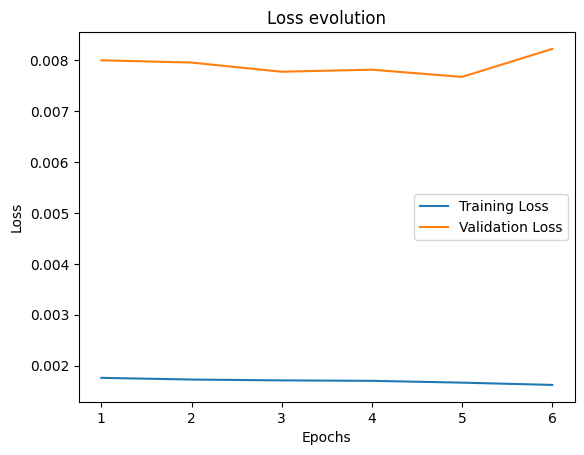

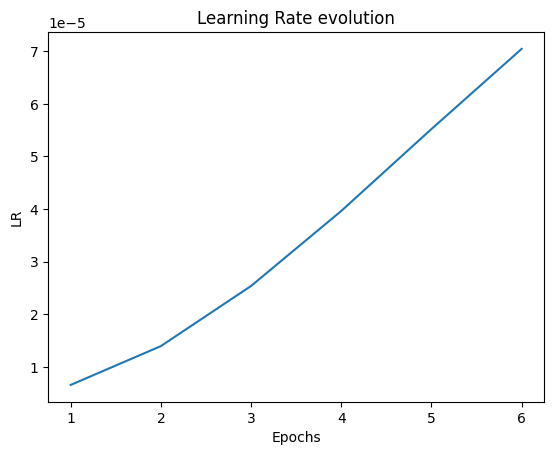


Fold : 1 Best Loss  : 0.007672
Fold : 1 Best Score : 0.922995

Fold 1 Done

OOF Shape : (7032, 237)
GT  Shape : (7032, 237)
Log Shape : (7032, 235)


In [30]:
for fold in cfg.FOLDS_LIST:
    print(f"{'>'.join('+*')*6} Fold {fold + 1} {'<'.join('*+')*6}")
    if fold == 0 or len(cfg.FOLDS_LIST) == 1:
        oof_df, oof_gt, oof_logits = train_loop(merge_df, ss_only, fold)
    else:
        _oof_df, _oof_gt, _oof_logits = train_loop(merge_df, ss_only, fold)
        oof_df     = pd.concat([oof_df, _oof_df], ignore_index=True)
        oof_gt     = pd.concat([oof_gt, _oof_gt], ignore_index=True)
        oof_logits = pd.concat([oof_logits, _oof_logits], ignore_index=True)
        
print(f"OOF Shape : {oof_df.shape}")
print(f"GT  Shape : {oof_gt.shape}")
print(f"Log Shape : {oof_logits.shape}")
oof_df     = oof_df.sort_values("row_id").reset_index(drop=True)
oof_gt     = oof_gt.sort_values("row_id").reset_index(drop=True)
oof_logits = oof_logits.sort_values("row_id").reset_index(drop=True)

assert oof_df["row_id"].equals(oof_gt["row_id"])
assert oof_df["row_id"].equals(oof_logits["row_id"])

### OOF & GT Save

In [31]:
oof_df.to_csv(os.path.join(OOF_DIR, "oof.csv"), index=False)
oof_gt.to_csv(os.path.join(OOF_DIR, "gt.csv"), index=False)
oof_logits.to_csv(os.path.join(OOF_DIR, "logits.csv"), index=False)

display(oof_df.head(3))
display(oof_gt.head(3))
display(oof_logits.head(3))

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1,is_ss,site
0,1161364_iNat1216197,0.000127,2.057436e-07,2.770060e-08,3.735552e-08,3.180350e-09,7.159812e-10,8.324593e-09,5.519156e-08,6.837702e-10,...,0.000009,8.365448e-10,1.712864e-10,3.475764e-09,3.807818e-13,4.471459e-08,1.149303e-07,5.290624e-07,0,None
1,1161364_iNat868369,0.000075,5.025004e-05,2.837076e-06,2.180940e-06,1.905575e-07,4.371978e-08,3.790704e-07,5.930819e-06,3.172580e-06,...,0.000057,2.017209e-04,2.910814e-07,1.952211e-07,1.633294e-07,1.150871e-05,4.111113e-05,2.514324e-06,0,None
2,116570_iNat1460166,0.000667,1.532250e-03,4.732206e-04,1.048713e-03,1.831398e-04,5.694358e-05,2.075680e-04,3.431027e-04,9.456983e-04,...,0.000253,1.403573e-03,1.097168e-04,2.930477e-04,2.708495e-04,9.171929e-04,3.851097e-04,1.892554e-04,0,None


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1,is_ss,site
0,1161364_iNat1216197,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,None
1,1161364_iNat868369,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,None
2,116570_iNat1460166,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,None


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,1161364_iNat1216197,-8.969712,-15.396635,-17.401812,-17.102785,-19.566275,-21.057367,-18.604052,-16.712456,-21.103399,...,-14.938430,-13.129137,-11.612732,-20.901741,-22.487684,-19.477451,-28.596550,-16.922966,-15.978940,-14.452159
1,1161364_iNat868369,-9.500896,-9.898449,-12.772734,-13.035752,-15.473311,-16.945465,-14.785543,-12.035342,-12.660962,...,-10.967030,-8.413920,-9.776580,-8.508424,-15.049663,-15.449133,-15.627497,-11.372395,-10.099191,-12.893504
2,116570_iNat1460166,-7.312273,-6.479485,-7.655476,-6.859143,-8.605078,-9.773393,-8.479844,-7.977138,-6.962641,...,-7.426314,-6.775161,-8.280421,-6.567330,-9.117498,-8.134882,-8.213676,-6.993275,-7.861597,-8.572224


### Score Roc AUC & Roc AUC Rank

In [32]:
species_cols = list(label2idx.keys())

gt_array = oof_gt[species_cols].values
pred     = oof_df[species_cols].values
mask     = gt_array.sum(axis=0) > 0

roc_auc  = roc_auc_score(gt_array[:, mask], pred[:, mask])
# Runk
y_pred_rank = np.argsort(np.argsort(pred, axis=1), axis=1) / pred.shape[1]
roc_auc_rank= roc_auc_score(gt_array[:, mask], y_pred_rank[:, mask])

print(f"AUC : {roc_auc:.6f}")
print(f"Rank: {roc_auc_rank:.6f}")

AUC : 0.930587
Rank: 0.921890


In [33]:
species_cols = list(label2idx.keys())

auc_list = []

for i, col in enumerate(species_cols):
    y_true = gt_array[:, i]
    y_pred = pred[:, i]

    # positiveがないクラスはスキップ
    if y_true.sum() == 0:
        continue

    auc = roc_auc_score(y_true, y_pred)
    auc_list.append({
        "species"  : col,
        "auc"      : auc,
        "pos_count": int(y_true.sum())
    })

auc_df = pd.DataFrame(auc_list)

In [34]:
auc_df.sort_values("auc").head(10)

,species,auc,pos_count
50,555123,0.532072,1
48,516975,0.572465,1
60,74113,0.590043,2
59,738183,0.627507,1
6,22930,0.638265,2
2,1176823,0.709531,2
134,nacnig1,0.721392,3
4,1595929,0.762480,1
25,41970,0.770998,5
162,rufcas2,0.772106,14


In [35]:
auc_df.sort_values("auc", ascending=False).head(10)

,species,auc,pos_count
40,47158son14,1.000000,2
43,47158son17,1.000000,2
57,67252,1.000000,1
45,47158son20,1.000000,1
33,47158son07,1.000000,4
32,47158son06,1.000000,2
35,47158son09,1.000000,2
46,47158son24,0.999964,4
11,22983,0.999929,2
28,47158son01,0.999929,2


In [36]:
auc_df.sort_values("pos_count").head(10)

,species,auc,pos_count
5,209233,0.948940,1
4,1595929,0.762480,1
15,23176,0.773859,1
13,23154,0.831603,1
12,22985,0.943536,1
29,47158son02,0.999147,1
31,47158son04,0.999573,1
23,25214,0.999431,1
48,516975,0.572465,1
50,555123,0.532072,1


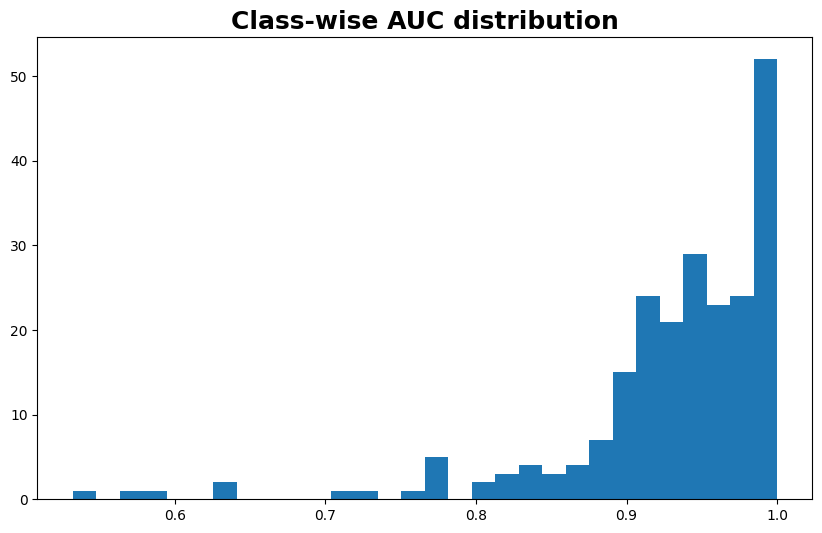

In [37]:
plt.figure(figsize=(10, 6))
plt.hist(auc_df["auc"], bins=30)
plt.title("Class-wise AUC distribution", size=18, fontweight="bold")
plt.show()